# Hard QAOA-ISAC Benchmark

This notebook version of `qaoa_isac_benchmark.py` runs the harder benchmark and displays the results in one place.

It keeps `qaoa_isac_notebook.ipynb` untouched. The original notebook remains the end-to-end Qiskit demo; this notebook is the competition-strength benchmark view.

Important framing: the strongest result below is a constraint-preserving valid-subspace QAOA simulation / QAOA-guided sampler. The optional hardware section prepares a full-binary QUBO QAOA circuit for IBM Quantum hardware; that hardware circuit does not yet implement the custom valid-subspace mixer directly.

## 1. Imports and Parameters

The headline benchmark now uses four UAVs:

- `U=4`, `G=6`, `S=6`, `Nt=4`
- full binary problem size: `24` qubits
- `Gamma_min=0.5`
- seed `67`

The suite below keeps the faster `U=3`, `G=6`, `S=5` setting and evaluates seeds `1:60` to show that the QAOA-guided local-search workflow is not just a single-seed result.

In [1]:
from argparse import Namespace
from pathlib import Path
import json
import math

import importlib

import matplotlib.pyplot as plt
import numpy as np

import qaoa_isac_benchmark as benchmark

# Rerunning notebook cells in an existing kernel can keep an older imported
# module in memory. Reload the local benchmark module so notebook execution
# always sees the current qaoa_isac_benchmark.py file.
importlib.invalidate_caches()
benchmark = importlib.reload(benchmark)
run_benchmark = benchmark.run_benchmark
run_suite = benchmark.run_suite
print_summary = benchmark.print_summary
generate_visualizations = benchmark.generate_visualizations

BENCHMARK_ARGS = Namespace(
    uavs=4,
    grid_points=6,
    survivors=6,
    antennas=4,
    gamma_min=0.5,
    seed=67,
    reps=1,
    grid_steps=81,
    shots=1024,
    top_k=12,
    local_top_k=8,
    random_trials=64,
    sweep_top_k="1,2,4,8,16",
    sweep_random_trials=64,
    output="qaoa_isac_benchmark_results.json",
    verbose=False,
)

SUITE_ARGS = Namespace(
    suite_seed_range="1:60",
    suite_uavs=3,
    suite_grid_points=6,
    suite_survivors=5,
    suite_antennas=4,
    suite_gamma_min=0.5,
    suite_grid_steps=31,
    suite_shots=1024,
    suite_top_k=8,
    suite_random_trials=32,
    suite_sweep_top_k="1,2,4,8,16",
    suite_sweep_random_trials=32,
    suite_stress_gap=0.10,
)

## 2. Run the Benchmark

This executes the 4-UAV showcase plus a multi-seed suite. The showcase reports exact enumeration, greedy, greedy plus local search, random feasible statistics, valid-subspace QAOA, and QAOA-top-K local search. The suite reports aggregate behavior over many seeds.

In [2]:
results = run_benchmark(BENCHMARK_ARGS)
results["suite"] = run_suite(SUITE_ARGS)
results["figures"] = generate_visualizations(results)
Path(BENCHMARK_ARGS.output).write_text(json.dumps(results, indent=2), encoding="utf-8")
print_summary(results)
print("\nSaved figures:")
for figure in results["figures"]:
    print(f"- {figure}")

Hard QAOA-ISAC benchmark
Scenario: U=4, G=6, S=6, n=24, Gamma_min=0.5, seed=67
Valid assignments: 329 feasible of 360 no-colocation states

Method                  Rate (Mbps)   AR_rate   Assignment
Exact enumeration            7.627     1.000   [2, 4, 1, 3]
Greedy                       6.186     0.811   [3, 2, 4, 1]
Greedy + local search        6.186     0.811   [3, 2, 4, 1]
Random feasible mean         5.820     0.763   -
Valid-subspace QAOA top      7.627     1.000   [2, 4, 1, 3]
QAOA top-8 + local         7.627     1.000   [2, 4, 1, 3]

QAOA optimum probability: 0.019 (6.2x uniform), 95% success in 157 shots vs 985 uniform shots
QAOA top-8+local AR=1.000; random top-8+local mean AR=0.993
Greedy gap: 18.9%; QAOA top gap: 0.0%

Top-K candidate efficiency sweep
K    QAOA AR   Random AR   QAOA gain   QAOA hit   Random hit
1       1.000       0.914       0.086   yes             0.141
2       1.000       0.949       0.051   yes             0.312
4       1.000       0.974       0.026   ye

## 3. Main Result Table

In [3]:
def mbps(value):
    return value / 1e6

rows = [
    {
        "method": "Exact enumeration",
        "sum_rate_mbps": mbps(results["exact"]["sum_rate"]),
        "AR_rate": results["exact"]["AR_rate"],
        "assignment": results["exact"]["assignment"],
        "feasible": results["exact"]["feasible"],
    },
    {
        "method": "Greedy",
        "sum_rate_mbps": mbps(results["greedy"]["sum_rate"]),
        "AR_rate": results["greedy"]["AR_rate"],
        "assignment": results["greedy"]["assignment"],
        "feasible": results["greedy"]["feasible"],
    },
    {
        "method": "Greedy + local search",
        "sum_rate_mbps": mbps(results["greedy_local_search"]["sum_rate"]),
        "AR_rate": results["greedy_local_search"]["AR_rate"],
        "assignment": results["greedy_local_search"]["assignment"],
        "feasible": results["greedy_local_search"]["feasible"],
    },
    {
        "method": "Random feasible mean",
        "sum_rate_mbps": mbps(results["random_feasible"]["mean_rate"]),
        "AR_rate": results["random_feasible"]["mean_AR_rate"],
        "assignment": "-",
        "feasible": True,
    },
    {
        "method": "Valid-subspace QAOA top",
        "sum_rate_mbps": mbps(results["valid_subspace_qaoa"]["top_assignment"]["sum_rate"]),
        "AR_rate": results["valid_subspace_qaoa"]["top_assignment"]["AR_rate"],
        "assignment": results["valid_subspace_qaoa"]["top_assignment"]["assignment"],
        "feasible": results["valid_subspace_qaoa"]["top_assignment"]["feasible"],
    },
    {
        "method": "QAOA top-8 + local",
        "sum_rate_mbps": mbps(results["qaoa_top_k_local_search"]["qaoa_best"]["sum_rate"]),
        "AR_rate": results["qaoa_top_k_local_search"]["qaoa_best"]["AR_rate"],
        "assignment": results["qaoa_top_k_local_search"]["qaoa_best"]["assignment"],
        "feasible": results["qaoa_top_k_local_search"]["qaoa_best"]["feasible"],
    },
]

try:
    import pandas as pd
    result_table = pd.DataFrame(rows)
    display(result_table)
except Exception:
    for row in rows:
        print(row)

{'method': 'Exact enumeration', 'sum_rate_mbps': 7.626835738324433, 'AR_rate': 1.0, 'assignment': [2, 4, 1, 3], 'feasible': True}
{'method': 'Greedy', 'sum_rate_mbps': 6.186467585750409, 'AR_rate': 0.8111447260708325, 'assignment': [3, 2, 4, 1], 'feasible': True}
{'method': 'Greedy + local search', 'sum_rate_mbps': 6.186467585750409, 'AR_rate': 0.8111447260708325, 'assignment': [3, 2, 4, 1], 'feasible': True}
{'method': 'Random feasible mean', 'sum_rate_mbps': 5.81976823116293, 'AR_rate': 0.763064582854317, 'assignment': '-', 'feasible': True}
{'method': 'Valid-subspace QAOA top', 'sum_rate_mbps': 7.626835738324433, 'AR_rate': 1.0, 'assignment': [2, 4, 1, 3], 'feasible': True}
{'method': 'QAOA top-8 + local', 'sum_rate_mbps': 7.626835738324433, 'AR_rate': 1.0, 'assignment': [2, 4, 1, 3], 'feasible': True}


## 4. QAOA Probability Distribution

The useful win signal is not just that the optimum exists in the feasible set. The valid-subspace QAOA distribution enriches the optimum relative to uniform feasible sampling.

In [4]:
qaoa = results["valid_subspace_qaoa"]
qaoa_local = results["qaoa_top_k_local_search"]
random = results["random_feasible"]

print(f"Optimum probability under QAOA: {qaoa['optimum_probability']:.6f}")
print(f"Uniform feasible optimum probability: {random['uniform_optimum_probability']:.6f}")
print(f"Enrichment vs uniform: {qaoa['enrichment_vs_uniform']:.2f}x")
print(f"Expected QAOA samples to optimum: {qaoa['expected_samples_to_optimum']:.2f}")
print(f"Expected uniform samples to optimum: {random['expected_samples_to_optimum']:.2f}")
print(f"Shots for 95% optimum-hit probability: {qaoa['shots_for_95pct_success']} QAOA vs {random['shots_for_95pct_success']} uniform")
print(f"QAOA top-{qaoa_local['top_k']} + local AR: {qaoa_local['qaoa_best']['AR_rate']:.3f}")
print(f"Random top-{qaoa_local['top_k']} + local mean AR: {qaoa_local['random_mean_AR_rate']:.3f}")
print(f"Random top-{qaoa_local['top_k']} + local optimum-hit rate: {qaoa_local['random_optimum_hit_rate']:.3f}")

prob_rows = qaoa["top_probabilities"]
top_k_sweep = results["top_k_sweep"]
try:
    import pandas as pd
    display(pd.DataFrame(prob_rows))
    display(pd.DataFrame(top_k_sweep)[[
        "top_k",
        "qaoa_AR_rate",
        "random_mean_AR_rate",
        "qaoa_gain_over_random_mean",
        "random_optimum_hit_rate",
        "qaoa_beats_random_trial_rate",
    ]])
except Exception:
    print(json.dumps(prob_rows, indent=2))
    print(json.dumps(top_k_sweep, indent=2))

Optimum probability under QAOA: 0.018982
Uniform feasible optimum probability: 0.003040
Enrichment vs uniform: 6.25x
Expected QAOA samples to optimum: 52.68
Expected uniform samples to optimum: 329.00
Shots for 95% optimum-hit probability: 157 QAOA vs 985 uniform
QAOA top-8 + local AR: 1.000
Random top-8 + local mean AR: 0.993
Random top-8 + local optimum-hit rate: 0.703
[
  {
    "assignment": [
      2,
      4,
      1,
      3
    ],
    "sum_rate": 7626835.738324434,
    "probability": 0.01898234716821428,
    "AR_rate": 1.0
  },
  {
    "assignment": [
      0,
      2,
      5,
      3
    ],
    "sum_rate": 6924864.513216539,
    "probability": 0.018375765366416608,
    "AR_rate": 0.9079603587657556
  },
  {
    "assignment": [
      2,
      5,
      1,
      3
    ],
    "sum_rate": 7037095.144562291,
    "probability": 0.017051519927997187,
    "AR_rate": 0.9226755873607283
  },
  {
    "assignment": [
      2,
      4,
      5,
      3
    ],
    "sum_rate": 7061239.8823247

## 5. Multi-Seed Suite

The suite is a faster `U=3, G=6, S=5` run over seeds `1:60`. It is not the same as the 4-UAV headline case; its purpose is to show the QAOA-guided top-K local-search workflow over repeated environments.

In [5]:
suite = results["suite"]
print(json.dumps({"scenario": suite["scenario"], "all": suite["all"], "stress": suite["stress"], "skipped_count": len(suite["skipped"])}, indent=2))

try:
    import pandas as pd
    suite_rows = pd.DataFrame(suite["rows"])
    display(suite_rows[[
        "seed",
        "feasible_assignment_count",
        "greedy_AR_rate",
        "greedy_local_AR_rate",
        "qaoa_top_AR_rate",
        "qaoa_top_k_local_AR_rate",
        "random_top_k_local_AR_rate",
        "qaoa_optimum_probability",
    ]])
    display(pd.DataFrame(suite["top_k_sweep"])[[
        "top_k",
        "mean_effective_top_k",
        "mean_qaoa_AR_rate",
        "mean_random_AR_rate",
        "qaoa_optimum_hits",
        "count",
        "mean_qaoa_gain_over_random",
    ]])
    display(pd.DataFrame(suite["stress_top_k_sweep"])[[
        "top_k",
        "mean_effective_top_k",
        "mean_qaoa_AR_rate",
        "mean_random_AR_rate",
        "qaoa_optimum_hits",
        "count",
        "mean_qaoa_gain_over_random",
    ]])
except Exception:
    compact_rows = [
        {
            "seed": row["seed"],
            "greedy_AR_rate": row["greedy_AR_rate"],
            "qaoa_top_k_local_AR_rate": row["qaoa_top_k_local_AR_rate"],
            "random_top_k_local_AR_rate": row["random_top_k_local_AR_rate"],
            "qaoa_optimum_probability": row["qaoa_optimum_probability"],
        }
        for row in suite["rows"]
    ]
    print(json.dumps(compact_rows, indent=2))
    print(json.dumps(suite["top_k_sweep"], indent=2))
    print(json.dumps(suite["stress_top_k_sweep"], indent=2))

{
  "scenario": {
    "U": 3,
    "G": 6,
    "S": 5,
    "Nt": 4,
    "n_qubits_full_binary": 18,
    "Gamma_min": 0.5,
    "seed_range": "1:60",
    "top_k": 8,
    "random_trials": 32,
    "sweep_top_k": [
      1,
      2,
      4,
      8,
      16
    ],
    "sweep_random_trials": 32,
    "stress_gap": 0.1
  },
  "all": {
    "count": 25,
    "mean_feasible_assignments": 31.56,
    "mean_greedy_AR_rate": 0.8964205278354249,
    "mean_greedy_local_AR_rate": 0.9117333436748257,
    "mean_qaoa_top_AR_rate": 0.9296209715718708,
    "mean_qaoa_top_k_local_AR_rate": 0.9992119144089444,
    "mean_random_top_k_local_AR_rate": 0.9901253547548748,
    "mean_qaoa_optimum_probability": 0.10118078500715465,
    "qaoa_top_k_optimum_hits": 23,
    "qaoa_top_k_beats_greedy": 21,
    "qaoa_top_k_beats_random_top_k": 17
  },
  "stress": {
    "count": 12,
    "mean_feasible_assignments": 33.416666666666664,
    "mean_greedy_AR_rate": 0.8254280454179196,
    "mean_greedy_local_AR_rate": 0.849982698

## 6. Saved Visualizations

These PNGs are generated by the benchmark harness and can be used directly in the final presentation.

figures\qaoa_convergence.png


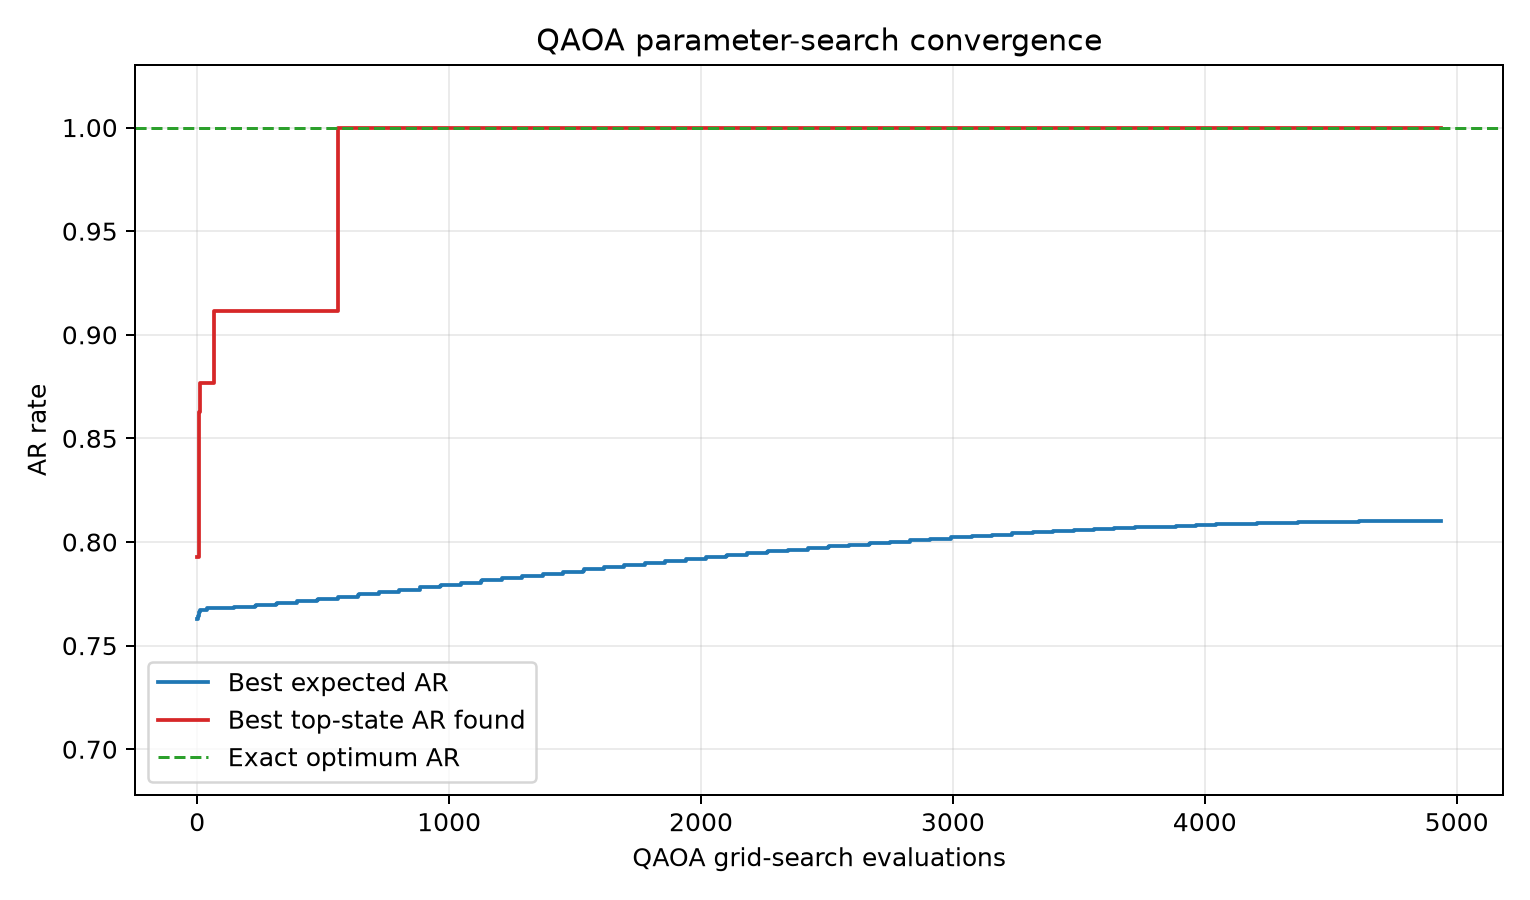

figures\qaoa_angle_landscape.png


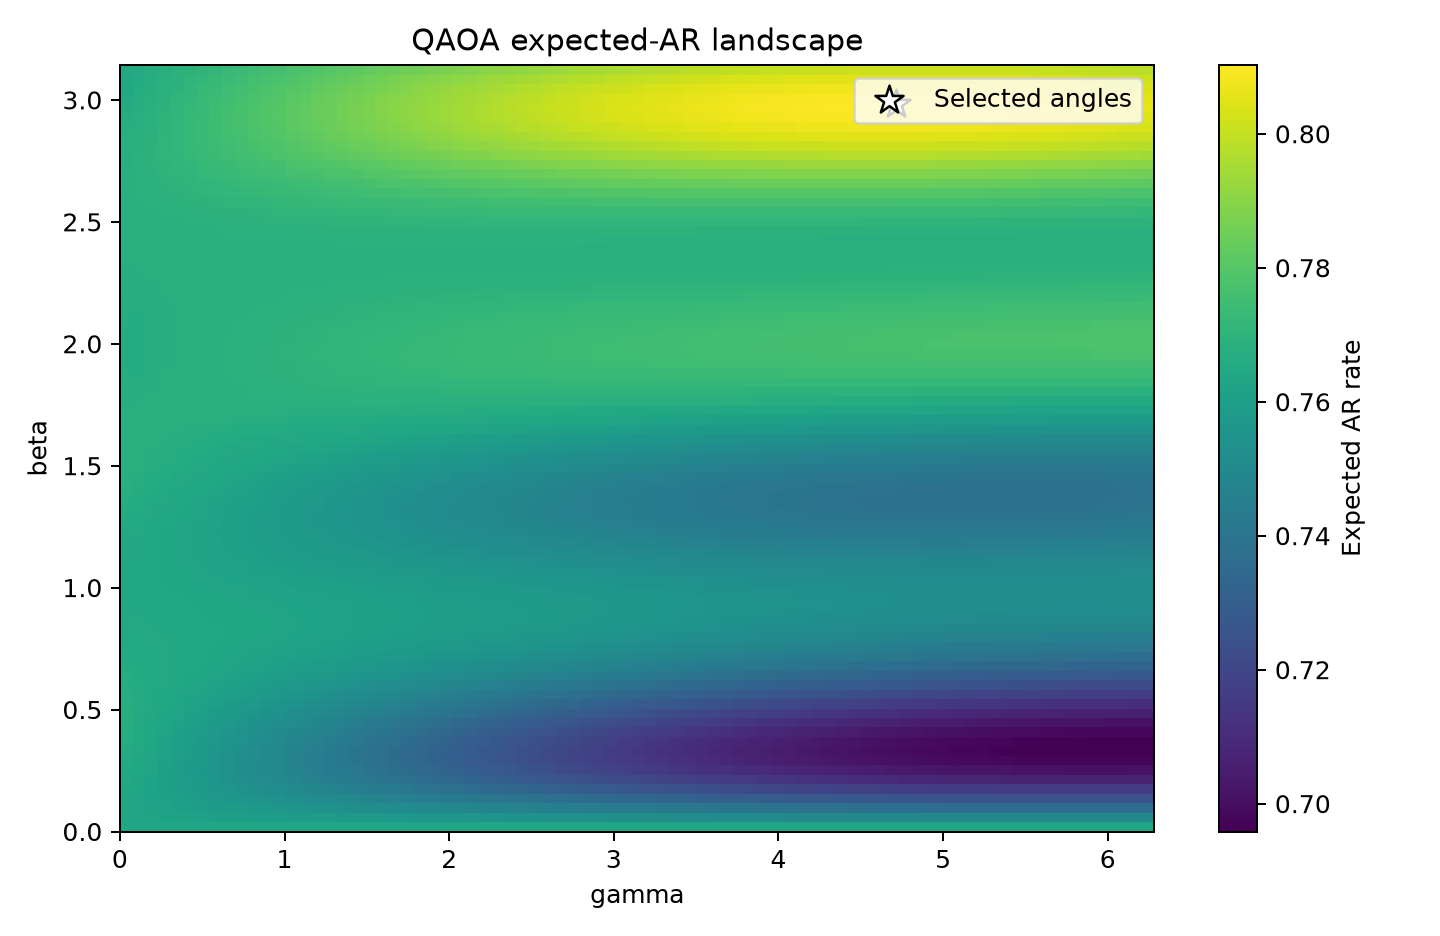

figures\qaoa_probability_distribution.png


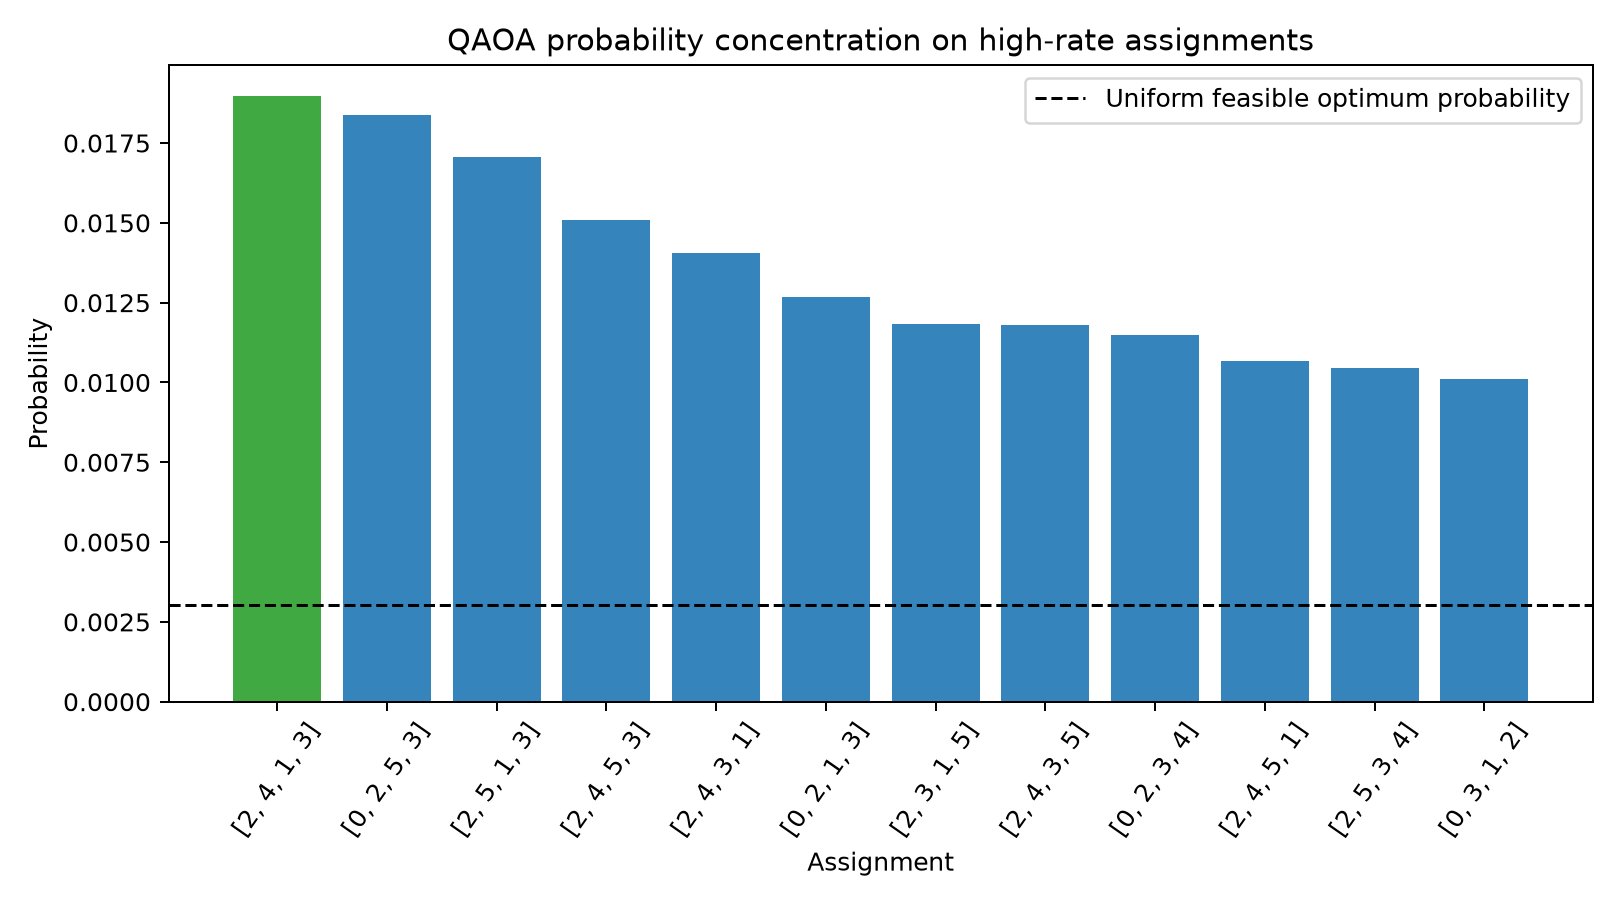

figures\qaoa_candidate_efficiency.png


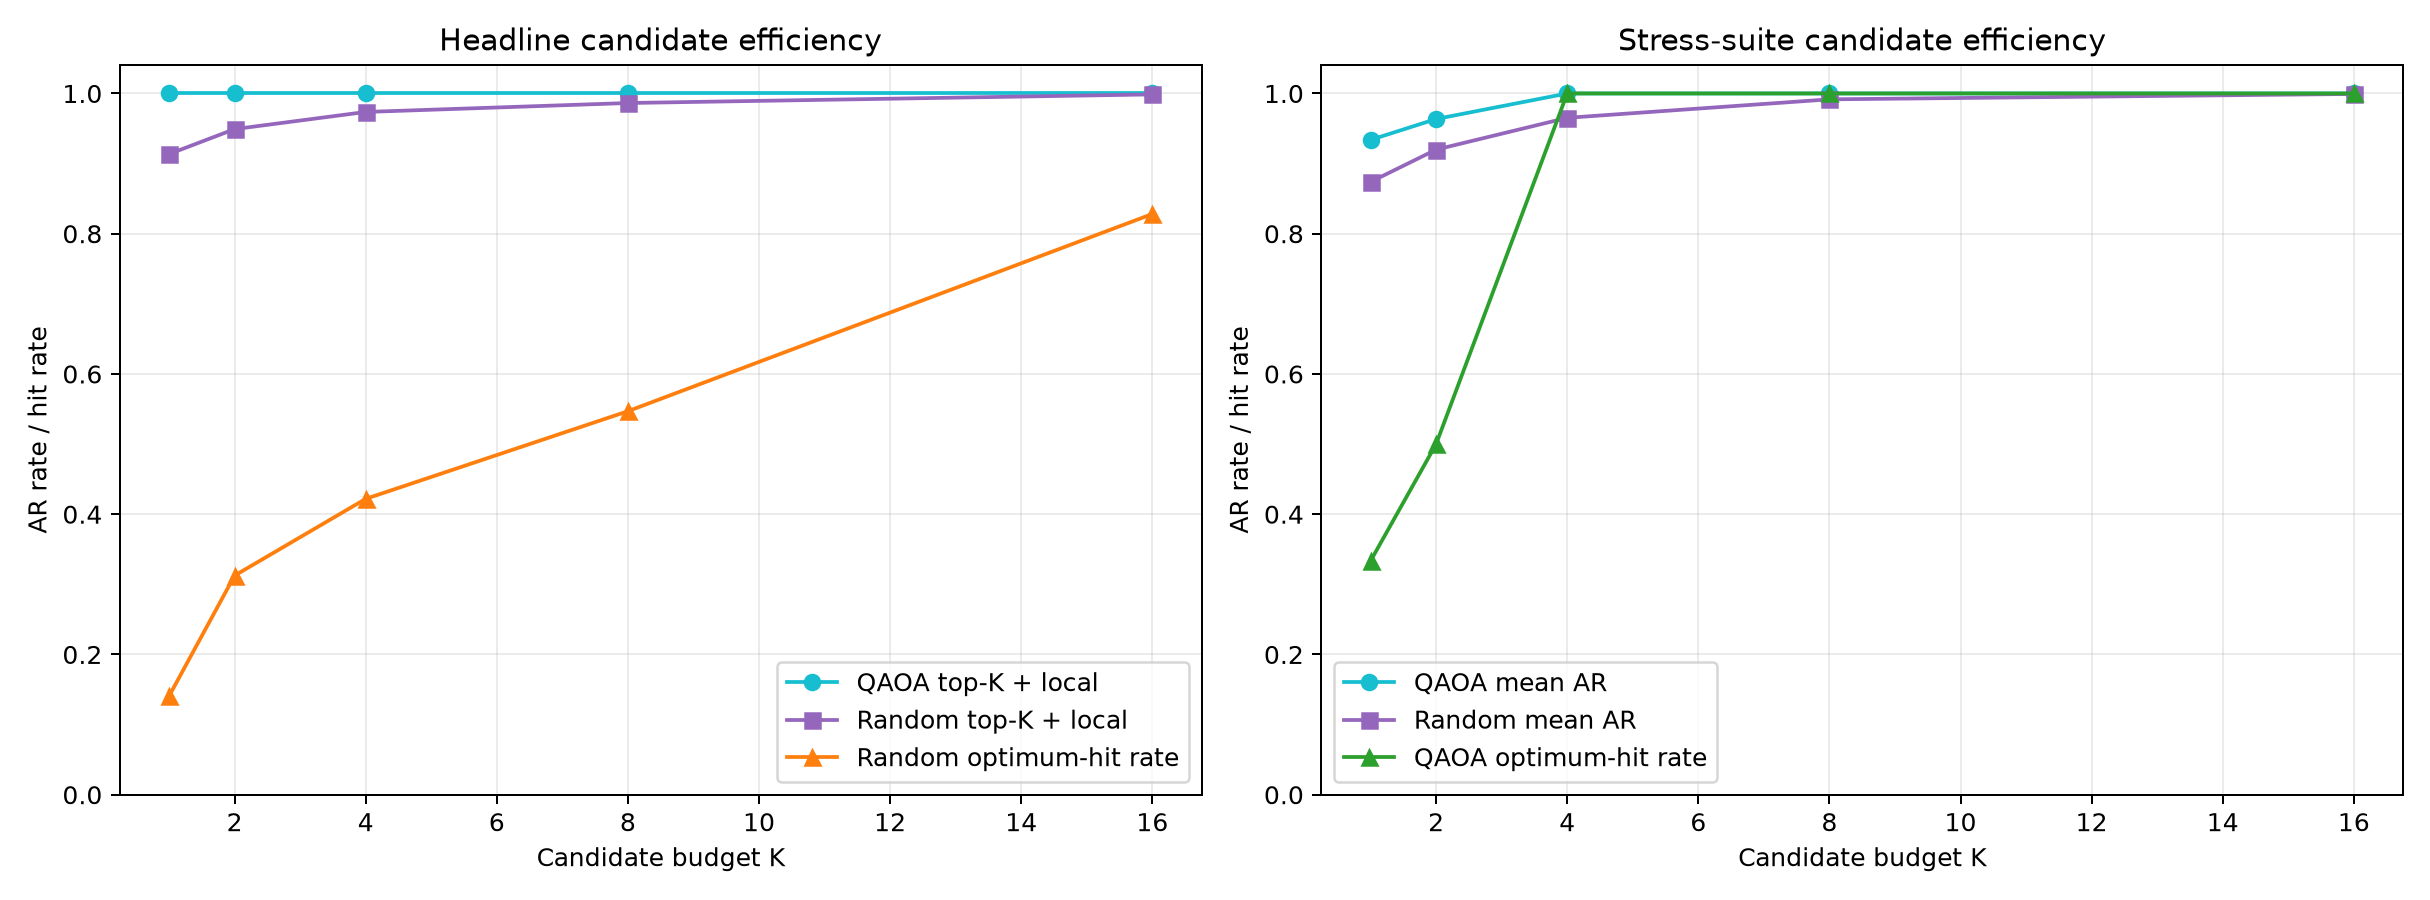

figures\qaoa_deployment_map.png


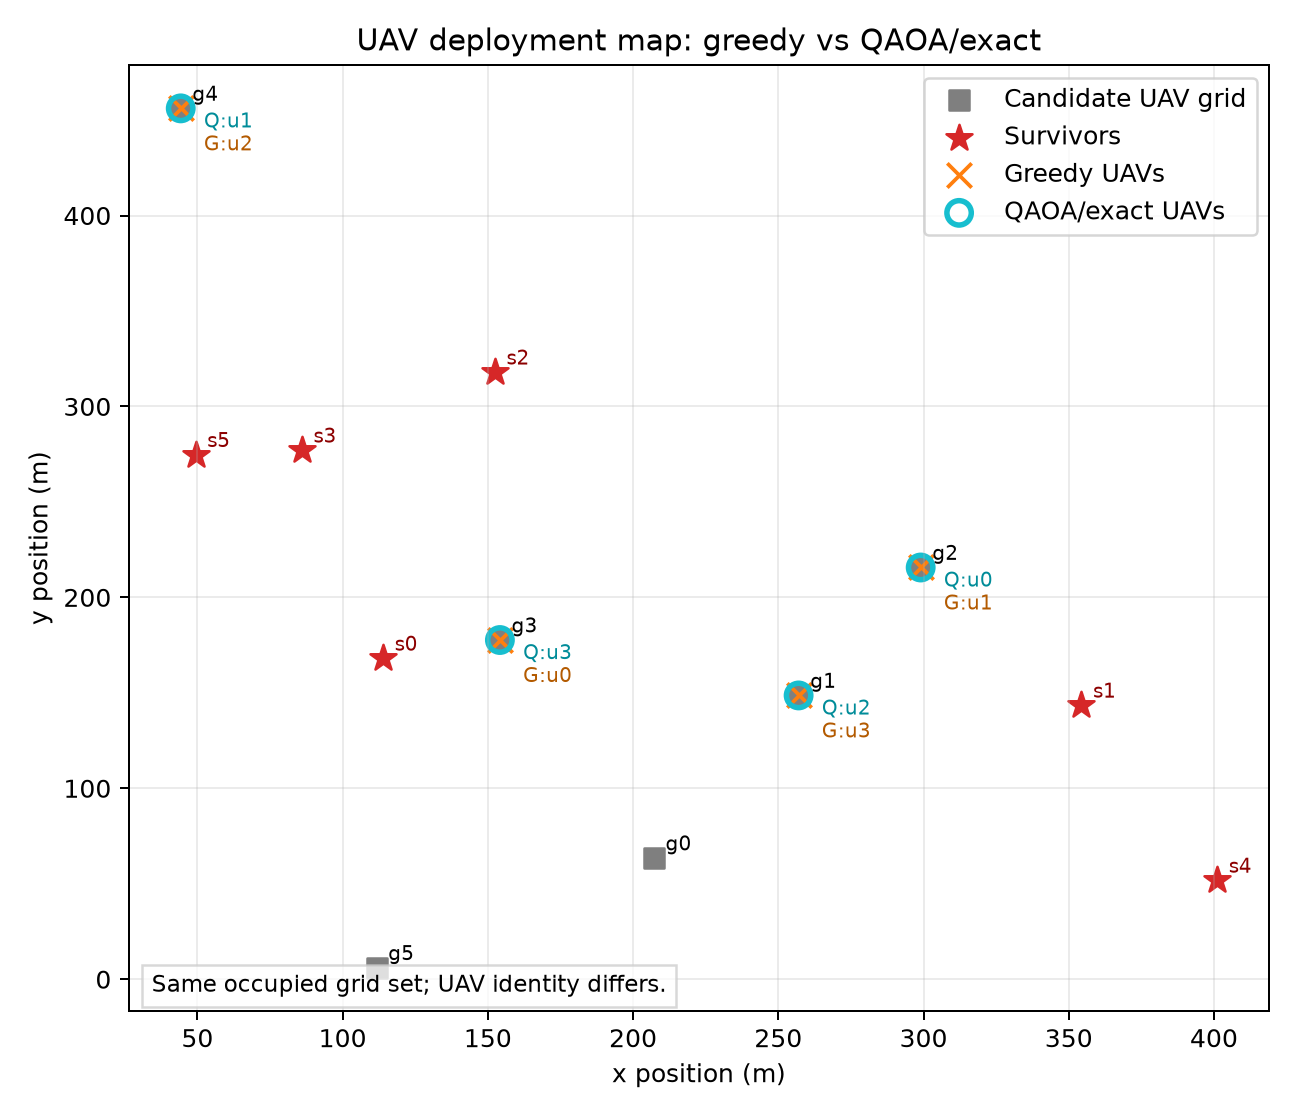

In [6]:
from IPython.display import Image, display

for figure in results["figures"]:
    print(figure)
    display(Image(filename=figure))

## 7. Full Results JSON

In [7]:
compact_results = {
    "scenario": results["scenario"],
    "exact": results["exact"],
    "greedy": results["greedy"],
    "valid_subspace_qaoa_summary": {
        key: results["valid_subspace_qaoa"][key]
        for key in [
            "gamma",
            "beta",
            "evaluations",
            "expected_AR_rate",
            "optimum_probability",
            "enrichment_vs_uniform",
            "shots_for_95pct_success",
        ]
    },
    "top_k_sweep": results["top_k_sweep"],
    "suite_summary": {
        "all": results["suite"]["all"],
        "stress": results["suite"]["stress"],
        "stress_top_k_sweep": results["suite"]["stress_top_k_sweep"],
    },
    "figures": results["figures"],
}
print(json.dumps(compact_results, indent=2))
print(f"Full results, including the angle landscape, are saved in {BENCHMARK_ARGS.output}.")

{
  "scenario": {
    "U": 4,
    "G": 6,
    "S": 6,
    "Nt": 4,
    "n_qubits_full_binary": 24,
    "Gamma_min": 0.5,
    "seed": 67,
    "valid_no_colocation_count": 360,
    "feasible_assignment_count": 329,
    "grid_points_xyz": [
      [
        207.16575,
        63.469151,
        131.724997
      ],
      [
        256.992518,
        148.621311,
        135.341533
      ],
      [
        299.018476,
        215.635276,
        146.844228
      ],
      [
        154.147134,
        177.650364,
        121.872996
      ],
      [
        44.258275,
        456.113758,
        83.842702
      ],
      [
        111.703595,
        6.006836,
        87.72453
      ]
    ],
    "survivors_xyz": [
      [
        113.927339,
        168.062846,
        0.0
      ],
      [
        354.364346,
        143.462583,
        0.0
      ],
      [
        152.427024,
        317.945134,
        0.0
      ],
      [
        85.968379,
        277.056873,
        0.0
      ],
      [
  

## 7. Optional IBM Quantum Hardware Run

These cells prepare code for a real IBM Quantum run. They are guarded so the notebook can be run safely without submitting a paid or queued hardware job.

What this hardware section does:

- Builds a full-binary QUBO QAOA circuit for the same `U=3, G=6, S=5` benchmark (`18` qubits).
- Uses the QUBO/Ising coefficients from `qaoa_isac_env.py`.
- Uses IBM Runtime `SamplerV2` with backend mode after ISA transpilation.
- Projects measured bitstrings back to feasible assignments for post-processing.

What it does not yet do:

- It does not compile the custom valid-subspace mixer used by the benchmark simulator. That would require a deeper custom circuit synthesis pass for the assignment graph mixer.

Before using real hardware, install Runtime support in the active environment and save your IBM Quantum credentials. IBM's current docs recommend `qiskit-ibm-runtime` for hardware jobs and show `QiskitRuntimeService()`, `service.least_busy(...)`, ISA transpilation with `generate_preset_pass_manager`, and `SamplerV2(mode=backend).run(..., shots=...)`.

In [8]:
# Hardware execution is opt-in. Leave this False for normal notebook runs.
SUBMIT_TO_HARDWARE = False

# Install if needed in the qiskit environment, then restart the kernel:
#   C:\Users\harry\.conda\envs\qiskit\python.exe -m pip install qiskit-ibm-runtime

# Save credentials once in a trusted local environment, replacing placeholders:
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account(token="<your-api-key>", instance="<CRN optional>", overwrite=True)

IBM_INSTANCE = None  # set to a CRN string if your account requires a specific instance
HARDWARE_SHOTS = 1024
HARDWARE_REPS = 1

# Starter angles. These are from the valid-subspace benchmark and are not claimed
# to be optimized for the full-binary hardware QUBO circuit.
GAMMA_HW = results["valid_subspace_qaoa"]["gamma"]
BETA_HW = results["valid_subspace_qaoa"]["beta"]

In [9]:
from collections import Counter

from qiskit import QuantumCircuit

from qaoa_isac_env import ISACEnvironment, SystemParams
from qaoa_isac_benchmark import build_environment, enumerate_assignments

hardware_params = SystemParams(
    U=results["scenario"]["U"],
    G=results["scenario"]["G"],
    S=results["scenario"]["S"],
    Nt=results["scenario"]["Nt"],
    Gamma_min=results["scenario"]["Gamma_min"],
)
hardware_env = build_environment(hardware_params, seed=results["scenario"]["seed"], quiet=True)
feasible_states = enumerate_assignments(hardware_env, require_c3=True)

def scaled_ising_terms(env):
    h = np.array(env.h_bias, dtype=float)
    j = np.array(env.J, dtype=float)
    scale = max(float(np.max(np.abs(h))), float(np.max(np.abs(j))), 1.0)
    return h / scale, j / scale, scale


def build_full_binary_qaoa_circuit(env, gamma, beta, reps=1, measure=True):
    # Build a hardware-executable p-layer QAOA circuit for the full binary QUBO.
    n_qubits = env.n_qubits
    circuit = QuantumCircuit(n_qubits, n_qubits if measure else 0)
    h, j, scale = scaled_ising_terms(env)

    circuit.h(range(n_qubits))
    for _ in range(reps):
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-12:
                circuit.rz(2.0 * gamma * coeff, i)
        for i in range(n_qubits):
            for k in range(i + 1, n_qubits):
                coeff = j[i, k]
                if abs(coeff) <= 1e-12:
                    continue
                circuit.cx(i, k)
                circuit.rz(2.0 * gamma * coeff, k)
                circuit.cx(i, k)
        for i in range(n_qubits):
            circuit.rx(2.0 * beta, i)

    if measure:
        circuit.measure(range(n_qubits), range(n_qubits))
    circuit.metadata = {
        "problem": "QAOA-ISAC full-binary QUBO",
        "U": env.params.U,
        "G": env.params.G,
        "S": env.params.S,
        "Gamma_min": env.params.Gamma_min,
        "qubo_scale": scale,
        "gamma": gamma,
        "beta": beta,
        "reps": reps,
    }
    return circuit


full_binary_circuit = build_full_binary_qaoa_circuit(
    hardware_env,
    gamma=GAMMA_HW,
    beta=BETA_HW,
    reps=HARDWARE_REPS,
    measure=True,
)

print(f"Hardware candidate circuit: {full_binary_circuit.num_qubits} qubits")
print(f"Depth before ISA transpilation: {full_binary_circuit.depth()}")
print(f"Ops before ISA transpilation: {full_binary_circuit.count_ops()}")

Hardware candidate circuit: 24 qubits
Depth before ISA transpilation: 139
Ops before ISA transpilation: OrderedDict({'cx': 552, 'rz': 300, 'h': 24, 'rx': 24, 'measure': 24})


In [10]:
def bitstring_to_variable_vector(bitstring, n_qubits):
    # Qiskit count strings are displayed with the highest classical bit first.
    return np.array([int(bit) for bit in bitstring[::-1][:n_qubits]], dtype=int)


def assignment_vector(row, env):
    x = np.zeros(env.n_qubits, dtype=int)
    for u, g in enumerate(row.assignment):
        x[u * env.params.G + g] = 1
    return x


def project_bitstring_to_feasible_assignment(bitstring, feasible_rows, env):
    bits = bitstring_to_variable_vector(bitstring, env.n_qubits)
    best_row = None
    best_key = None
    for row in feasible_rows:
        candidate = assignment_vector(row, env)
        hamming = int(np.sum(bits != candidate))
        key = (-hamming, row.sum_rate)
        if best_key is None or key > best_key:
            best_key = key
            best_row = row
    return best_row


def summarize_hardware_counts(counts, feasible_rows, env, exact_rate):
    repaired = Counter()
    for bitstring, count in counts.items():
        row = project_bitstring_to_feasible_assignment(bitstring, feasible_rows, env)
        repaired[row.assignment] += count

    summary = []
    lookup = {row.assignment: row for row in feasible_rows}
    for assignment, count in repaired.most_common(10):
        row = lookup[assignment]
        summary.append({
            "assignment": list(assignment),
            "count": int(count),
            "probability": count / sum(counts.values()),
            "sum_rate_mbps": row.sum_rate / 1e6,
            "AR_rate": row.sum_rate / exact_rate,
        })
    return summary

print("Post-processing helpers are ready.")

Post-processing helpers are ready.


In [11]:
if SUBMIT_TO_HARDWARE:
    from qiskit.transpiler import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService
    from qiskit_ibm_runtime import SamplerV2 as Sampler

    service = QiskitRuntimeService(instance=IBM_INSTANCE) if IBM_INSTANCE else QiskitRuntimeService()
    backend = service.least_busy(
        simulator=False,
        operational=True,
        min_num_qubits=full_binary_circuit.num_qubits,
    )
    print(f"Selected backend: {backend.name}")

    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(full_binary_circuit)
    print(f"Depth after ISA transpilation: {isa_circuit.depth()}")
    print(f"Ops after ISA transpilation: {isa_circuit.count_ops()}")

    sampler = Sampler(mode=backend)
    job = sampler.run([(isa_circuit,)], shots=HARDWARE_SHOTS)
    print(f"Job ID: {job.job_id()}")
    print(f"Initial status: {job.status()}")
else:
    print("SUBMIT_TO_HARDWARE is False. Set it to True only when you are ready to submit a real IBM Quantum job.")

SUBMIT_TO_HARDWARE is False. Set it to True only when you are ready to submit a real IBM Quantum job.


In [12]:
# Run this cell after a real hardware job completes.
# It assumes a variable named `job` exists from the submission cell.
if "job" in globals():
    hardware_result = job.result()
    hardware_counts = hardware_result[0].data.meas.get_counts()
    hardware_summary = summarize_hardware_counts(
        hardware_counts,
        feasible_states,
        hardware_env,
        exact_rate=results["exact"]["sum_rate"],
    )
    try:
        import pandas as pd
        display(pd.DataFrame(hardware_summary))
    except Exception:
        print(json.dumps(hardware_summary, indent=2))
else:
    print("No hardware job is available yet. Submit a job first, or retrieve one by job ID with QiskitRuntimeService().job('<job-id>').")

No hardware job is available yet. Submit a job first, or retrieve one by job ID with QiskitRuntimeService().job('<job-id>').
